In [10]:
# Importing libraries
from lumicks import pylake

import matplotlib.pyplot as plt
import os
import statistics


In [11]:
def frame_tick_function(frame_ticks,offset):
    frame_tick_labels = []
    for frame_tick in frame_ticks:
        if frame_tick % 5 == 0:
            frame_tick_labels.append(frame_tick+offset)
        else:
            frame_tick_labels.append("")

    return frame_tick_labels

IndexError: list index out of range

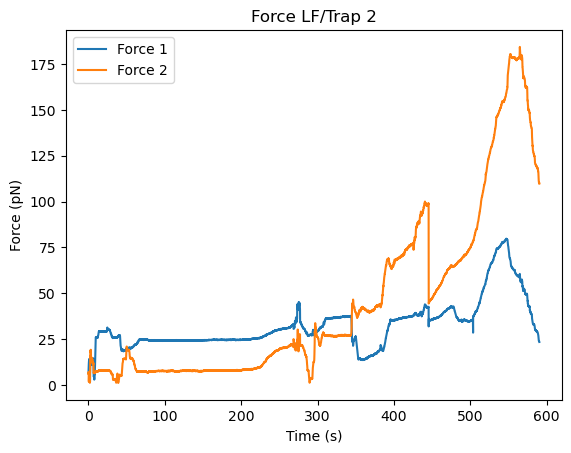

In [12]:
# Setting parameters
root = '/Users/gfisher/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Documents/Data/C-trap/_Analysis/2025_09_19_Comparison of DNA breakage forces with and without SYTOX/'

crop_ranges = {'10':(19,37),'29':(14,35)}

# print(os.listdir(root))
for path in os.listdir(root):
    out_name, ext = os.path.splitext(root+path)

    # Only processing H5 files
    if (ext != ".h5"):
        continue
    
    # Loading data
    file = pylake.File(root+path)

    # Iterating over all scans in the file
    for scan in file.scans.values():        
        # Getting all timestamps in this file
        timestamps = file.downsampled_force1.timestamps

        # For each frame's time window, get all timestamps and calculate average force, etc.
        timestamp0 = scan.frame_timestamp_ranges()[0][0]
        results = []
        for (idx,(f_start,f_end)) in enumerate(scan.frame_timestamp_ranges()):
            f_timestamps = [timestamp > f_start and timestamp < f_end for timestamp in timestamps]

            force1 = statistics.mean(file.downsampled_force1.data[f_timestamps])
            force2 = statistics.mean(file.downsampled_force2.data[f_timestamps])
        
            results.append([idx,f_start,(f_start-timestamp0)/1E9,f_end,(f_end-timestamp0)/1E9,force1])
            
        # Plotting force as a function of time
        plt.figure()
        file.downsampled_force1.plot() 
        file.downsampled_force2.plot()
        plt.legend(['Force 1','Force 2'])
        ax1 = plt.gca()
        ax1.set_title("Scan "+scan.name+" (frametime = "+str((results[1][1]-results[0][1])/1E9)+"s)")
        
        # Cropping to preferred x range
        if scan.name in crop_ranges.keys():
            crop_range = crop_ranges[scan.name]
            ax1.set_xlim((results[crop_range[0]-1][2],results[crop_range[1]-1][2]))
            frame_ticks = range(crop_range[1]-crop_range[0]+1)
            frame_offset = crop_range[0]
        else:
            ax1.set_xlim((0,(timestamps[-1]-timestamp0)/1E9))
            frame_ticks = range(len(scan.frame_timestamp_ranges()))
            frame_offset = 1
            
        # Adding top axis        
        ax2 = ax1.twiny()        
        ax2.set_xticks(frame_ticks)
        ax2.set_xticklabels(frame_tick_function(frame_ticks, frame_offset))
        plt.savefig(out_name+"_scan"+scan.name+"_forcetime.svg")
                        